# C9 Demo - Advanced deep learning for computer vision
**Chương 9 - Học sâu nâng cao cho thị giác máy tính**

Notebook này minh họa các ý chính của Chapter 9 trong *Deep Learning with Python, 2nd Edition*:

- Ba tác vụ thị giác máy tính cốt lõi: **classification**, **segmentation**, **object detection**.
- Ví dụ **semantic segmentation** bằng mô hình encoder-decoder.
- Ba mẫu kiến trúc convnet hiện đại: **residual connections**, **batch normalization**, **depthwise separable convolutions**.
- Ba hướng diễn giải convnet: **intermediate activations**, **filter visualization**, **Grad-CAM**.

Lưu ý: để demo chạy nhanh trong lớp, phần segmentation dùng **dữ liệu ảnh tổng hợp** thay vì tải bộ Oxford-IIIT Pets. Nguyên lý mô hình và loss vẫn giống tinh thần trong sách.

## 0. Chuẩn bị môi trường

Chạy cell này trước để import thư viện, cố định seed và cấu hình hiển thị. Nếu máy chưa có TensorFlow, cần cài TensorFlow trước khi chạy notebook.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Cố định seed để kết quả sinh dữ liệu và huấn luyện có tính lặp lại.
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Giảm bớt log của TensorFlow để phần output trong notebook gọn hơn.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Cấu hình kích thước hình mặc định để các biểu đồ dễ nhìn trên notebook.
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = False

print("TensorFlow:", tf.__version__)
print("Thiết bị đang dùng:", tf.config.list_physical_devices())

I0000 00:00:1781166917.437945   45917 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781166918.078091   45917 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781166920.566752   45917 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Thiết bị đang dùng: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Ba tác vụ cốt lõi: classification, segmentation, detection

Một ảnh có thể được dùng cho nhiều tác vụ khác nhau:

- **Image classification**: dự đoán nhãn cho toàn ảnh.
- **Image segmentation**: dự đoán nhãn cho từng pixel.
- **Object detection**: dự đoán bounding box và class cho từng đối tượng.

Cell dưới đây tạo một ảnh tổng hợp có hình tròn và hình chữ nhật để minh họa ba kiểu đầu ra.

In [2]:
IMAGE_SIZE = 96
NUM_CLASSES = 3
CLASS_NAMES = ["background", "circle", "rectangle"]

# Mỗi class trong segmentation mask được gán một màu để trực quan hóa.
MASK_COLORS = np.array(
    [
        [20, 20, 40],      # background: xanh đen
        [255, 210, 70],    # circle: vàng
        [80, 200, 255],    # rectangle: xanh cyan
    ],
    dtype="uint8",
)


def make_synthetic_scene(image_size=IMAGE_SIZE, seed=None):
    """Tạo một ảnh tổng hợp, semantic mask và bounding boxes."""
    # Tạo bộ sinh số ngẫu nhiên riêng để mỗi ảnh có vị trí hình khác nhau.
    rng = np.random.default_rng(seed)

    # Khởi tạo ảnh nền có nhiễu nhẹ để mô hình không chỉ học màu phẳng tuyệt đối.
    image = np.ones((image_size, image_size, 3), dtype="float32") * 30
    image += rng.normal(loc=0, scale=4, size=image.shape)

    # Mask semantic lưu class id cho từng pixel: 0 là nền, 1 là hình tròn, 2 là hình chữ nhật.
    mask = np.zeros((image_size, image_size), dtype="uint8")

    # Lưới tọa độ giúp tạo hình tròn bằng công thức khoảng cách Euclid.
    yy, xx = np.mgrid[:image_size, :image_size]
    boxes = []

    # Sinh hình tròn với tâm và bán kính ngẫu nhiên.
    radius = int(rng.integers(image_size // 10, image_size // 6))
    cx = int(rng.integers(radius + 4, image_size - radius - 4))
    cy = int(rng.integers(radius + 4, image_size - radius - 4))
    circle_region = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    image[circle_region] = np.array([255, 210, 70])
    mask[circle_region] = 1
    boxes.append(("circle", cx - radius, cy - radius, cx + radius, cy + radius))

    # Sinh hình chữ nhật với kích thước và vị trí ngẫu nhiên.
    rect_w = int(rng.integers(image_size // 5, image_size // 3))
    rect_h = int(rng.integers(image_size // 6, image_size // 3))
    x1 = int(rng.integers(4, image_size - rect_w - 4))
    y1 = int(rng.integers(4, image_size - rect_h - 4))
    x2 = x1 + rect_w
    y2 = y1 + rect_h
    image[y1:y2, x1:x2] = np.array([80, 200, 255])
    mask[y1:y2, x1:x2] = 2
    boxes.append(("rectangle", x1, y1, x2, y2))

    # Ép giá trị ảnh về miền [0, 255] và đổi sang uint8 để hiển thị như ảnh RGB.
    image = np.clip(image, 0, 255).astype("uint8")
    return image, mask, boxes


def colorize_mask(mask):
    """Đổi mask class id thành ảnh màu để nhìn trực quan hơn."""
    return MASK_COLORS[mask]

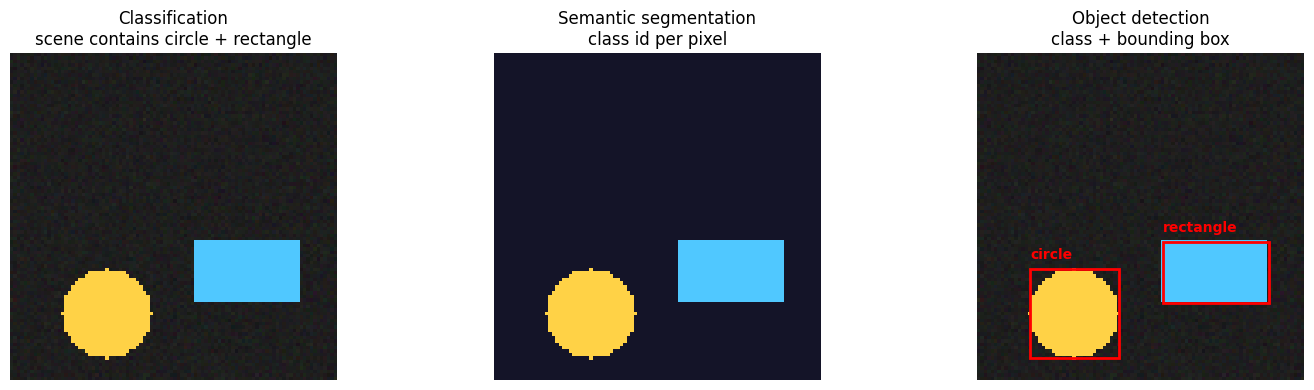

In [3]:
# Tạo một ảnh demo cố định để so sánh ba tác vụ trên cùng một input.
image, mask, boxes = make_synthetic_scene(seed=10)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Classification chỉ cần một nhãn cấp ảnh, không cần chỉ ra vị trí đối tượng.
axes[0].imshow(image)
axes[0].set_title("Classification\nscene contains circle + rectangle")
axes[0].axis("off")

# Segmentation cần một nhãn cho từng pixel, nên đầu ra là một ảnh mask.
axes[1].imshow(colorize_mask(mask))
axes[1].set_title("Semantic segmentation\nclass id per pixel")
axes[1].axis("off")

# Detection cần bounding box và class cho từng đối tượng trong ảnh.
axes[2].imshow(image)
for class_name, x1, y1, x2, y2 in boxes:
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    axes[2].add_patch(rect)
    axes[2].text(x1, y1 - 3, class_name, color="red", fontsize=10, weight="bold")
axes[2].set_title("Object detection\nclass + bounding box")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 2. Demo semantic segmentation bằng encoder-decoder

Trong sách, segmentation được minh họa bằng Oxford-IIIT Pets. Ở đây ta dùng dữ liệu tổng hợp để chạy nhanh:

- Input: ảnh RGB kích thước `96 x 96 x 3`.
- Target: mask kích thước `96 x 96 x 1`, mỗi pixel là class id.
- Model: encoder dùng `Conv2D(strides=2)` để giảm mẫu, decoder dùng `Conv2DTranspose` để phóng to lại.
- Loss: `sparse_categorical_crossentropy`, vì mask chứa số nguyên class id.

In [ ]:
def build_arrays(num_samples, seed_offset=0):
    """Sinh mảng ảnh và mask để đưa vào tf.data.Dataset."""
    images = []
    masks = []

    # Mỗi sample dùng một seed khác nhau để tạo nhiều vị trí và kích thước hình.
    for i in range(num_samples):
        image, mask, _ = make_synthetic_scene(seed=seed_offset + i)
        images.append(image)
        masks.append(mask[..., np.newaxis])

    # Chuyển list Python thành numpy array để TensorFlow đọc hiệu quả hơn.
    images = np.array(images, dtype="uint8")
    masks = np.array(masks, dtype="uint8")
    return images, masks


TRAIN_SAMPLES = 320
VAL_SAMPLES = 80
BATCH_SIZE = 16

# Tạo tập train và validation nhỏ để demo chạy nhanh trên CPU.
train_images, train_masks = build_arrays(TRAIN_SAMPLES, seed_offset=0)
val_images, val_masks = build_arrays(VAL_SAMPLES, seed_offset=10_000)

# Dataset là iterator tạo batch; shuffle làm dữ liệu vào model ngẫu nhiên hơn.
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
train_ds = train_ds.shuffle(512, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Validation không cần shuffle vì chỉ dùng để đánh giá.
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_masks))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Train images:", train_images.shape)
print("Train masks:", train_masks.shape)

I0000 00:00:1781166924.862027   45917 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6207 MB memory:  -> device: 0, name: NVIDIA RTX A2000 8GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Train images: (320, 96, 96, 3)
Train masks: (320, 96, 96, 1)


In [ ]:
def build_segmentation_model(image_size=IMAGE_SIZE, num_classes=NUM_CLASSES):
    """Xây mô hình segmentation encoder-decoder nhỏ."""
    inputs = keras.Input(shape=(image_size, image_size, 3), name="input_image")

    # Rescaling đưa pixel từ [0, 255] về [0, 1] để tối ưu ổn định hơn.
    x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)

    # Encoder giảm kích thước không gian và tăng số kênh đặc trưng.
    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu", name="encoder_conv_1")(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu", name="encoder_conv_2")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu", name="encoder_conv_3")(x)

    # Decoder phóng to feature map để quay về độ phân giải ban đầu của mask.
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_1")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_2")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu", name="decoder_deconv_3")(x)

    # Layer cuối dự đoán phân phối xác suất trên 3 class tại từng pixel.
    outputs = layers.Conv2D(num_classes, 3, padding="same", activation="softmax", name="pixel_classifier")(x)
    return keras.Model(inputs, outputs, name="toy_segmentation_model")


seg_model = build_segmentation_model()

# Loss sparse categorical crossentropy dùng được vì mask chứa class id nguyên.
seg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

seg_model.summary()

Model: "toy_segmentation_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_1                │ (None, 24, 24, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_2                │ (None, 48, 48, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv_3                │ (None, 96, 96, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_classifier (Conv2D)       │ (None, 96, 96, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 5

# EarlyStopping dừng sớm nếu validation loss không cải thiện, giúp demo không train quá lâu.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )
]

# Huấn luyện model segmentation trên dữ liệu tổng hợp.
history = seg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/5


I0000 00:00:1781166930.270155   46313 service.cc:153] XLA service 0x59f81c5cdf30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781166930.270196   46313 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1781166930.339328   46313 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1781166930.515654   46313 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1781166930.790605   46313 cuda_dnn.cc:461] Loaded cuDNN version 92101


13/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8310 - loss: 1.0373

I0000 00:00:1781166943.396599   46313 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8415 - loss: 1.0093

W0000 00:00:1781166944.025417   46310 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - accuracy: 0.8796 - loss: 0.8474 - val_accuracy: 0.8897 - val_loss: 0.4761
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8922 - loss: 0.2231 - val_accuracy: 0.8897 - val_loss: 0.1518
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9213 - loss: 0.1336 - val_accuracy: 0.9449 - val_loss: 0.1087
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9448 - loss: 0.1052 - val_accuracy: 0.9453 - val_loss: 0.0980
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9490 - loss: 0.0896 - val_accuracy: 0.9497 - val_loss: 0.0847


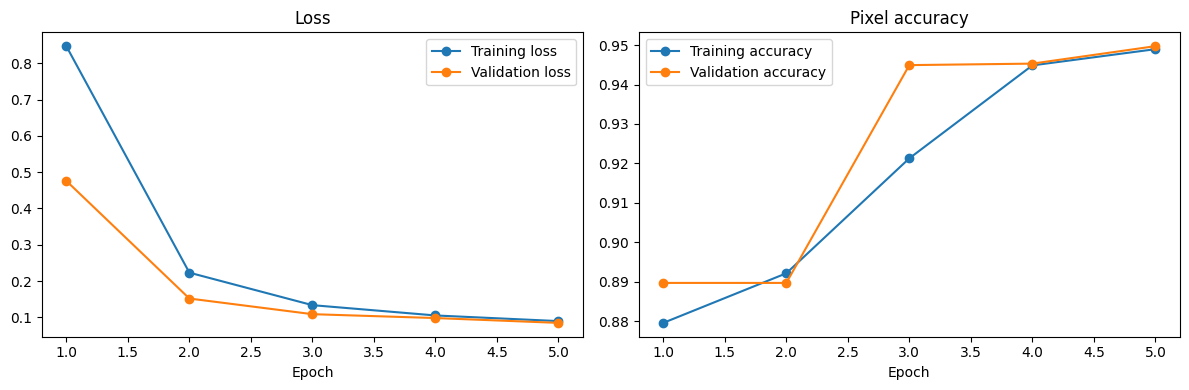

In [7]:
def plot_training_history(history):
    """Vẽ loss và accuracy để quan sát quá trình học của model."""
    metrics = history.history
    epochs = range(1, len(metrics["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss cho biết sai số tối ưu; validation loss giúp phát hiện overfitting.
    axes[0].plot(epochs, metrics["loss"], "o-", label="Training loss")
    axes[0].plot(epochs, metrics["val_loss"], "o-", label="Validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Accuracy pixel đo tỉ lệ pixel được dự đoán đúng class.
    axes[1].plot(epochs, metrics["accuracy"], "o-", label="Training accuracy")
    axes[1].plot(epochs, metrics["val_accuracy"], "o-", label="Validation accuracy")
    axes[1].set_title("Pixel accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


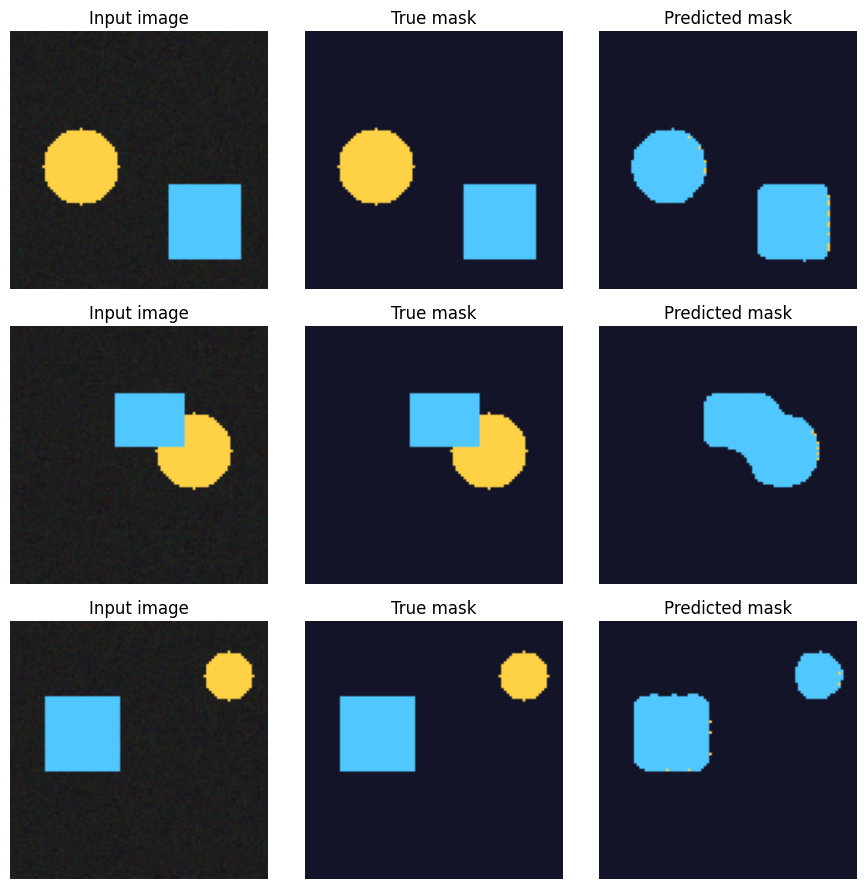

In [8]:
# Lấy một batch validation để xem model dự đoán mask như thế nào.
sample_images, sample_masks = next(iter(val_ds))
pred_probs = seg_model.predict(sample_images[:3])

# argmax chọn class có xác suất cao nhất tại từng pixel.
pred_masks = np.argmax(pred_probs, axis=-1).astype("uint8")

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i in range(3):
    # Cột 1 là ảnh input.
    axes[i, 0].imshow(sample_images[i].numpy().astype("uint8"))
    axes[i, 0].set_title("Input image")
    axes[i, 0].axis("off")

    # Cột 2 là mask thật.
    true_mask = sample_masks[i].numpy().squeeze()
    axes[i, 1].imshow(colorize_mask(true_mask))
    axes[i, 1].set_title("True mask")
    axes[i, 1].axis("off")

    # Cột 3 là mask model dự đoán.
    axes[i, 2].imshow(colorize_mask(pred_masks[i]))
    axes[i, 2].set_title("Predicted mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 3. Các mẫu kiến trúc convnet hiện đại

Chapter 9 nhấn mạnh ba ý tưởng thường xuất hiện trong convnet hiện đại:

- **Residual connections**: giúp gradient và thông tin đi qua mạng sâu dễ hơn.
- **Batch normalization**: ổn định phân phối activation trung gian.
- **Depthwise separable convolution**: giảm số tham số bằng cách tách lọc không gian và trộn channel.

In [9]:
def count_params_for_layer(layer):
    """Tạo một model một layer để đếm số tham số trainable."""
    inputs = keras.Input(shape=(32, 32, 64))
    outputs = layer(inputs)
    model = keras.Model(inputs, outputs)
    return model.count_params()


# Conv2D chuẩn trộn không gian và channel trong cùng một phép tích chập.
standard_params = count_params_for_layer(
    layers.Conv2D(64, 3, padding="same", use_bias=False)
)

# SeparableConv2D tách thành depthwise convolution và pointwise convolution.
separable_params = count_params_for_layer(
    layers.SeparableConv2D(64, 3, padding="same", use_bias=False)
)

print("Số tham số Conv2D chuẩn:", standard_params)
print("Số tham số SeparableConv2D:", separable_params)
print("Tỉ lệ giảm tham số:", round(standard_params / separable_params, 2), "lần")

Số tham số Conv2D chuẩn: 36864
Số tham số SeparableConv2D: 4672
Tỉ lệ giảm tham số: 7.89 lần


In [10]:
def residual_block(x, filters, stride=1, name="residual_block"):
    """Residual block dùng Conv2D -> BN -> ReLU và shortcut projection khi cần."""
    residual = x

    # Nhánh chính học phần biến đổi F(x).
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    # Nếu shape thay đổi, shortcut cũng cần được chiếu sang shape mới trước khi cộng.
    if residual.shape[-1] != filters or stride != 1:
        residual = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False, name=f"{name}_projection")(residual)

    # Cộng nhánh chính với shortcut để tạo y = F(x) + x.
    x = layers.add([x, residual], name=f"{name}_add")
    x = layers.Activation("relu", name=f"{name}_out")(x)
    return x


# Xây một model nhỏ kiểu ResNet để minh họa residual connection và BatchNormalization.
inputs = keras.Input(shape=(64, 64, 3), name="input")
x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)
x = layers.Conv2D(32, 3, padding="same", use_bias=False, name="stem_conv")(x)
x = layers.BatchNormalization(name="stem_bn")(x)
x = layers.Activation("relu", name="stem_relu")(x)
x = residual_block(x, 32, stride=1, name="block1")
x = residual_block(x, 64, stride=2, name="block2")
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
outputs = layers.Dense(3, activation="softmax", name="classifier")(x)
residual_demo_model = keras.Model(inputs, outputs, name="residual_demo_model")

residual_demo_model.summary()

Model: "residual_demo_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 64, 64,    │      9,216 │ stem_relu[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 64, 64,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu1        │ (None, 64, 64,    │          0 │ block1_bn1[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 64, 64,    │      9,216 │ block1_relu1[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 64, 64,    │        128 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 64, 64,    │          0 │ block1_bn2[0][0], │
│                     │ 32)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_out          │ (None, 64, 64,    │          0 │ block1_add[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 32, 32,    │     18,432 │ block1_out[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn1          │ (None, 32, 32,    │        256 │ block2_conv1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_relu1        │ (None, 32, 32,    │          0 │ block2_bn1[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 32, 32,    │     36,864 │ block2_relu1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn2          │ (None, 32, 32,    │        256 │ block2_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 77,731 (303.64 KB)

 Trainable params: 77,283 (301.89 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
def xception_like_block(x, filters, stride=2, name="xception_like_block"):
    """Block kiểu Xception thu nhỏ: BN -> ReLU -> SeparableConv2D và residual projection."""
    residual = x

    # Chuỗi BN -> ReLU -> SeparableConv2D giúp ổn định training và giảm số tham số.
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_sepconv1")(x)

    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_sepconv2")(x)

    # MaxPooling giảm kích thước không gian, còn projection shortcut giữ shape tương thích.
    x = layers.MaxPooling2D(3, strides=stride, padding="same", name=f"{name}_pool")(x)
    residual = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False, name=f"{name}_projection")(residual)
    x = layers.add([x, residual], name=f"{name}_add")
    return x


inputs = keras.Input(shape=(96, 96, 3), name="input")
x = layers.Rescaling(1.0 / 255, name="rescaling")(inputs)
x = layers.Conv2D(32, 5, padding="same", use_bias=False, name="entry_conv")(x)

# Lặp block với số filter tăng dần để tạo cấu trúc phân cấp đặc trưng.
for filters in [32, 64, 128]:
    x = xception_like_block(x, filters, name=f"xception_block_{filters}")

x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.3, name="dropout")(x)
outputs = layers.Dense(2, activation="softmax", name="classifier")(x)
xception_demo_model = keras.Model(inputs, outputs, name="mini_xception_like_model")

xception_demo_model.summary()

Model: "mini_xception_like_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 96, 96, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ input[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv (Conv2D) │ (None, 96, 96,    │      2,400 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │        128 │ entry_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │          0 │ xception_block_3… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │      1,312 │ xception_block_3… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │        128 │ xception_block_3… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │          0 │ xception_block_3… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 96, 96,    │      1,312 │ xception_block_3… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │          0 │ xception_block_3… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │      1,024 │ entry_conv[0][0]  │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_32_… │ (None, 48, 48,    │          0 │ xception_block_3… │
│ (Add)               │ 32)               │            │ xception_block_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │        128 │ xception_block_3… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │          0 │ xception_block_6… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │      2,336 │ xception_block_6… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │        256 │ xception_block_6… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_block_64_… │ (None, 48, 48,    │          0 │ xception_block_6… │
│ (Activation)        │ 64)               │            │                 

 Total params: 51,266 (200.26 KB)

 Trainable params: 50,562 (197.51 KB)

 Non-trainable params: 704 (2.75 KB)

## 4. Diễn giải những gì convnet học được

Phần này minh họa ba kỹ thuật trong Chapter 9:

- Xem **activation trung gian** của các layer.
- Dùng **gradient ascent** để tìm pattern làm một filter kích hoạt mạnh.
- Dùng **Grad-CAM** để tìm vùng ảnh quan trọng cho một class.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


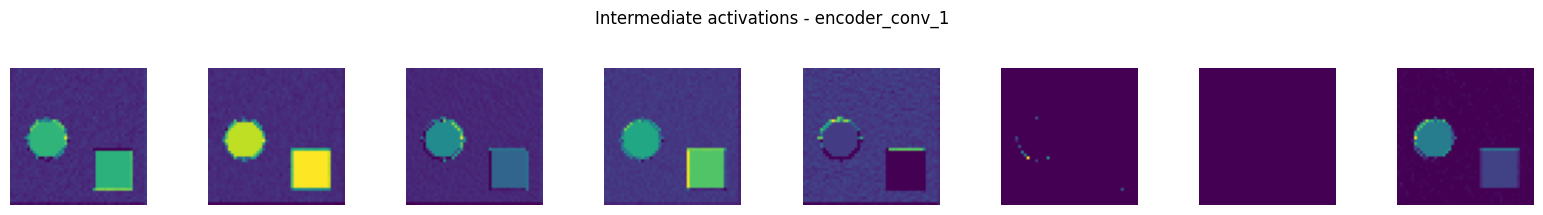

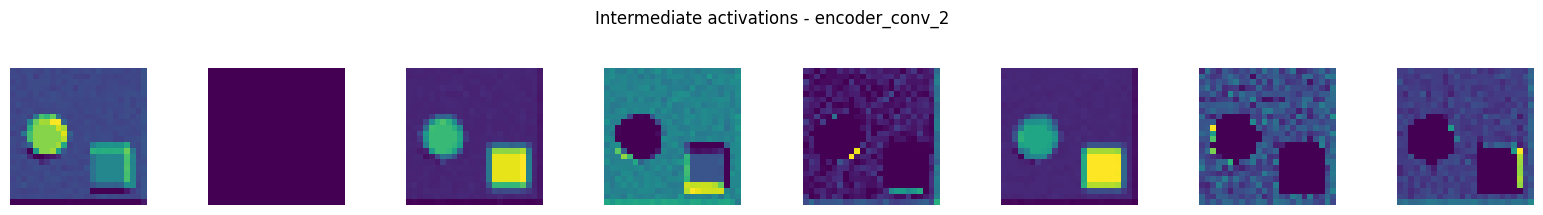

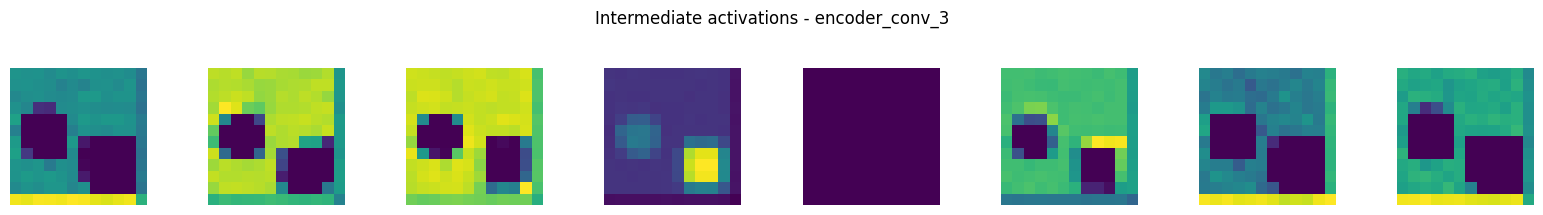

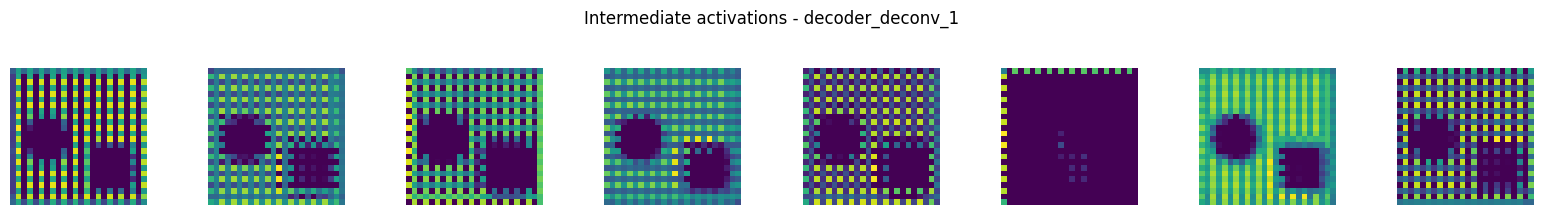

In [12]:
# Chọn một ảnh validation để đưa qua model segmentation đã train.
test_image = sample_images[:1]

# Lấy output của một số layer convolution để quan sát feature maps trung gian.
layer_names = ["encoder_conv_1", "encoder_conv_2", "encoder_conv_3", "decoder_deconv_1"]
layer_outputs = [seg_model.get_layer(name).output for name in layer_names]
activation_model = keras.Model(seg_model.input, layer_outputs)

# Dự đoán activation cho ảnh mẫu.
activations = activation_model.predict(test_image)

# Mỗi layer hiển thị tối đa 8 channel đầu tiên để notebook không quá dài.
for layer_name, activation in zip(layer_names, activations):
    num_channels = min(8, activation.shape[-1])
    fig, axes = plt.subplots(1, num_channels, figsize=(2 * num_channels, 2))
    fig.suptitle(f"Intermediate activations - {layer_name}", y=1.05)

    for channel_index in range(num_channels):
        # Lấy feature map 2D của một channel.
        channel_image = activation[0, :, :, channel_index]

        # Chuẩn hóa feature map để hiển thị rõ hơn trên thang màu.
        channel_image = channel_image - channel_image.mean()
        channel_image = channel_image / (channel_image.std() + 1e-6)

        axes[channel_index].imshow(channel_image, cmap="viridis")
        axes[channel_index].axis("off")

    plt.tight_layout()
    plt.show()

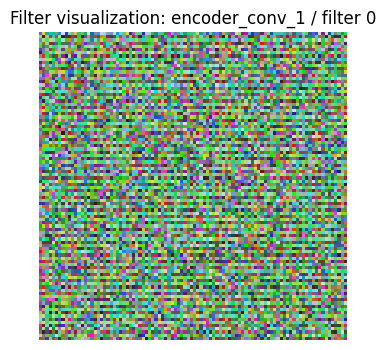

In [13]:
def deprocess_image(x):
    """Đưa tensor ảnh về dạng uint8 để hiển thị."""
    # Chuẩn hóa ảnh quanh mean và scale để pattern dễ nhìn hơn.
    x = x - x.mean()
    x = x / (x.std() + 1e-6)
    x = x * 64 + 128
    x = np.clip(x, 0, 255).astype("uint8")
    return x


def generate_filter_pattern(model, layer_name, filter_index=0, steps=40, learning_rate=10.0):
    """Tạo ảnh đầu vào làm một filter cụ thể kích hoạt mạnh bằng gradient ascent."""
    # Feature extractor trả về activation của layer đang quan sát.
    feature_extractor = keras.Model(model.input, model.get_layer(layer_name).output)

    # Khởi tạo ảnh ngẫu nhiên trong miền pixel [0, 255].
    image = tf.Variable(tf.random.uniform((1, IMAGE_SIZE, IMAGE_SIZE, 3), minval=0, maxval=255))

    for step in range(steps):
        with tf.GradientTape() as tape:
            # Tính activation của layer mục tiêu trên ảnh hiện tại.
            activation = feature_extractor(image)

            # Loss là activation trung bình của filter cần trực quan hóa.
            loss = tf.reduce_mean(activation[:, :, :, filter_index])

        # Gradient cho biết cần thay đổi pixel thế nào để loss tăng nhanh nhất.
        grads = tape.gradient(loss, image)
        grads = grads / (tf.sqrt(tf.reduce_mean(tf.square(grads))) + 1e-6)

        # Gradient ascent: cập nhật ảnh theo hướng làm filter kích hoạt mạnh hơn.
        image.assign_add(learning_rate * grads)
        image.assign(tf.clip_by_value(image, 0, 255))

    return deprocess_image(image.numpy()[0])


# Thử xem filter đầu tiên của encoder_conv_1 thích pattern nào.
pattern = generate_filter_pattern(seg_model, layer_name="encoder_conv_1", filter_index=0)

plt.figure(figsize=(4, 4))
plt.imshow(pattern)
plt.title("Filter visualization: encoder_conv_1 / filter 0")
plt.axis("off")
plt.show()

## 5. Grad-CAM với mô hình pretrained

Cell dưới đây dùng **MobileNetV2 pretrained trên ImageNet** để minh họa Grad-CAM. Sách dùng Xception, nhưng MobileNetV2 nhẹ hơn nên phù hợp demo trên lớp. Ý tưởng Grad-CAM là giống nhau: xem vùng ảnh nào làm class score tăng mạnh.

Cell này cần internet ở lần chạy đầu để tải weights và ảnh mẫu. Nếu không có internet, notebook sẽ in thông báo và bỏ qua phần này.

In [14]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Tạo Grad-CAM heatmap cho một ảnh và một class dự đoán."""
    # Model phụ trả về cả feature map cuối và vector dự đoán.
    grad_model = keras.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output],
    )

    with tf.GradientTape() as tape:
        # Forward pass để lấy activation cuối và logits.
        last_conv_output, preds = grad_model(img_array)

        # Nếu không chỉ định class, dùng class có score cao nhất.
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient đo mức ảnh hưởng của từng vị trí/channel đến class score.
    grads = tape.gradient(class_channel, last_conv_output)

    # Lấy trung bình gradient theo không gian để có trọng số quan trọng cho từng channel.
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Nhân từng channel activation với trọng số quan trọng của channel đó.
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Chỉ giữ phần đóng góp dương và chuẩn hóa về [0, 1].
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-6)
    return heatmap.numpy(), int(pred_index)


def overlay_heatmap(img_path, heatmap, alpha=0.4):
    """Chồng heatmap lên ảnh gốc để dễ diễn giải."""
    # Đọc ảnh gốc ở dạng numpy array.
    img = keras.utils.load_img(img_path)
    img = keras.utils.img_to_array(img).astype("uint8")

    # Đổi heatmap [0, 1] thành ảnh màu jet.
    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = plt.colormaps["jet"]
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = np.uint8(jet_colors[heatmap_uint8] * 255)

    # Resize heatmap về đúng kích thước ảnh gốc.
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap).astype("uint8")

    # Trộn ảnh gốc với heatmap; alpha càng lớn thì màu heatmap càng rõ.
    superimposed = np.uint8(img * (1 - alpha) + jet_heatmap * alpha)
    return img, superimposed


try:
    # Tải MobileNetV2 pretrained; include_top=True để có classifier ImageNet.
    cam_model = keras.applications.MobileNetV2(weights="imagenet")

    # Bỏ softmax cuối để gradient theo logits ổn định hơn khi tính Grad-CAM.
    cam_model.layers[-1].activation = None

    # Ảnh voi giống tinh thần ví dụ Grad-CAM trong sách.
    img_path = keras.utils.get_file(
        "african_elephant.jpg",
        "https://i.imgur.com/Bvro0YD.png",
    )

    # Tiền xử lý ảnh theo đúng chuẩn MobileNetV2.
    img = keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = keras.applications.mobilenet_v2.preprocess_input(img_array)

    # Dự đoán class và giải mã top-3 class để đọc được bằng tên người.
    preds = cam_model.predict(img_array)
    decoded = keras.applications.mobilenet_v2.decode_predictions(tf.nn.softmax(preds).numpy(), top=3)[0]
    print("Top-3 dự đoán:")
    for class_id, class_name, score in decoded:
        print(f"- {class_name}: {score:.3f}")

    # Conv_1 là layer convolution cuối lớn của MobileNetV2.
    heatmap, pred_index = make_gradcam_heatmap(
        img_array,
        cam_model,
        last_conv_layer_name="Conv_1",
    )

    original, cam_image = overlay_heatmap(img_path, heatmap, alpha=0.4)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap="jet")
    axes[1].set_title("Grad-CAM heatmap")
    axes[1].axis("off")

    axes[2].imshow(cam_image)
    axes[2].set_title("Heatmap overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

except Exception as exc:
    print("Không chạy được demo Grad-CAM pretrained.")
    print("Lý do thường gặp: chưa có internet để tải weights hoặc ảnh mẫu.")
    print("Chi tiết lỗi:", exc)

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Không chạy được demo Grad-CAM pretrained.
Lý do thường gặp: chưa có internet để tải weights hoặc ảnh mẫu.
Chi tiết lỗi: URL fetch failure on https://i.imgur.com/Bvro0YD.png: 429 -- Unknown Error


## Gợi ý thảo luận sau demo

1. Vì sao segmentation cần giữ thông tin vị trí tốt hơn classification?
2. Residual connection giúp ích gì cho gradient khi mạng rất sâu?
3. BatchNormalization khác gì so với việc chỉ chuẩn hóa input ban đầu?
4. Vì sao `SeparableConv2D` có ít tham số hơn `Conv2D` chuẩn?
5. Grad-CAM giúp phát hiện những lỗi nào trong mô hình thị giác máy tính?